CUDA available: True
CUDA device count: 1
Current device: 0
Device name: NVIDIA GeForce RTX 4090
Device: cuda
C:\Users\User\Desktop\Final project comp3710\keras_slices_data\keras_slices_train OK
C:\Users\User\Desktop\Final project comp3710\keras_slices_data\keras_slices_seg_train OK
C:\Users\User\Desktop\Final project comp3710\keras_slices_data\keras_slices_validate OK
C:\Users\User\Desktop\Final project comp3710\keras_slices_data\keras_slices_seg_validate OK
C:\Users\User\Desktop\Final project comp3710\keras_slices_data\keras_slices_test OK
C:\Users\User\Desktop\Final project comp3710\keras_slices_data\keras_slices_seg_test OK
Train: 11460 | Val: 660 | Test: 540
Sample shapes: (1, 256, 256) (256, 256) labels 0 … 1
Epoch 01/2 | Train Loss 0.0167 | Train Dice 0.8089 | Val Dice 0.7311 | Best 0.7311
Epoch 02/2 | Train Loss 0.0044 | Train Dice 0.8948 | Val Dice 0.8471 | Best 0.8471
Training complete. Best Val Dice: 0.8470509502408011
TEST Dice (prostate): 0.9463


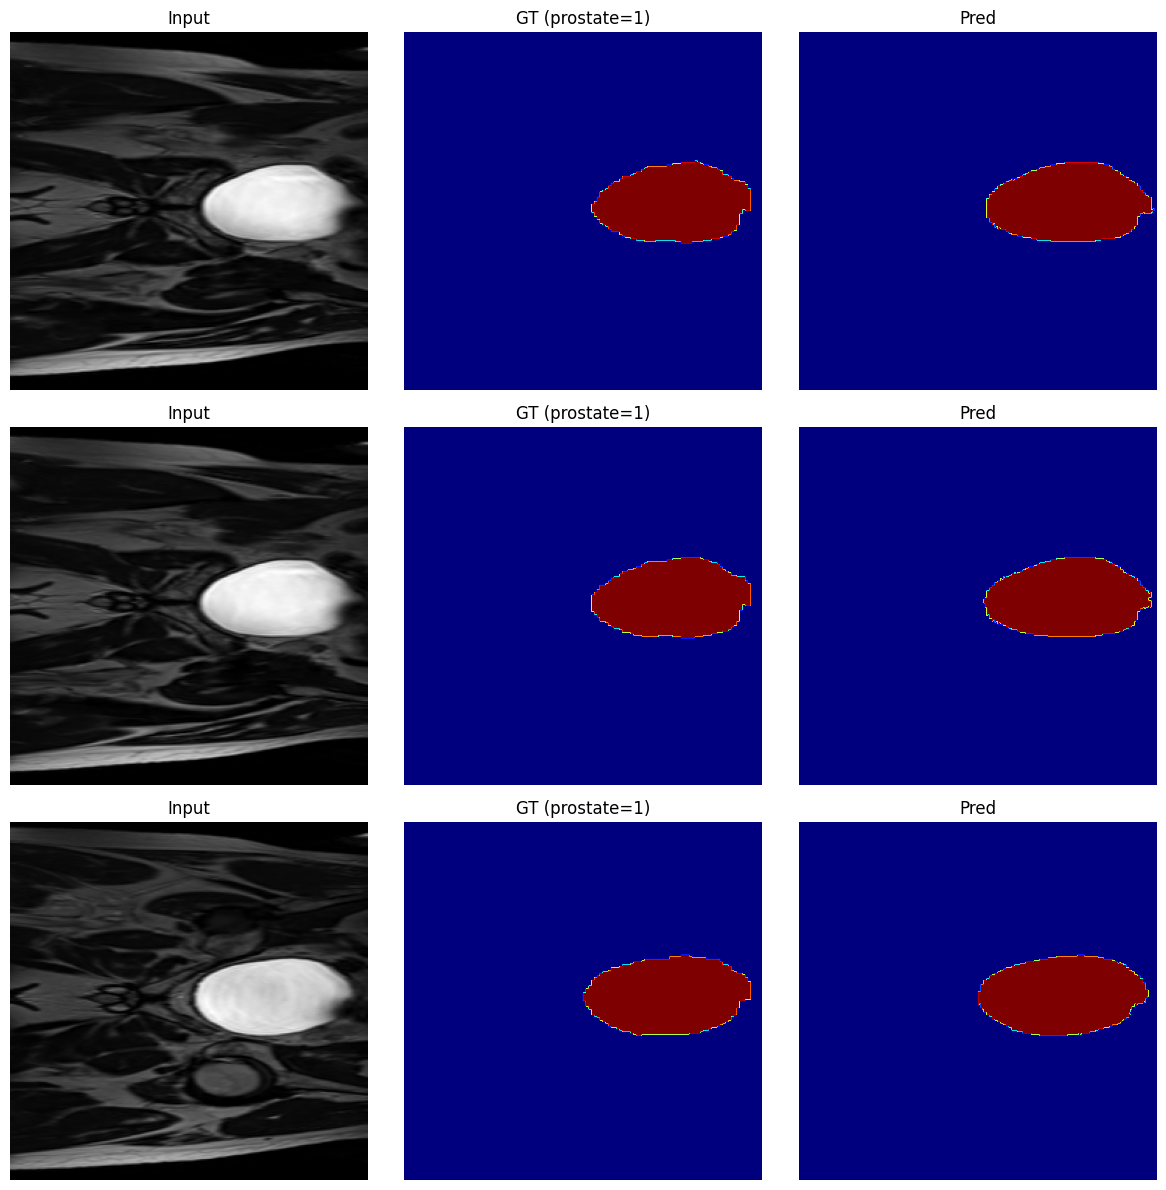

Best checkpoint: models/unet2d_can_hipmri_best.pth


In [4]:
# Project 3: HipMRI 2D Prostate Segmentation with U-Net + 2D CAN (PyTorch)
# =========================================================================
# This notebook:
#  - Loads HipMRI 2D slices (NIfTI) with robust image/mask pairing
#  - Resizes to 256x256 (consistent batching)
#  - Uses U-Net with a CANBlock (dilated convs) at the bottleneck
#  - Trains with CrossEntropyLoss, reports Dice on val/test
#  - Saves best checkpoint and visualises predictions

# --- 0) Imports & config ---
import os, glob, re
from pathlib import Path
from typing import Tuple

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "None")
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# --- 1) Paths (EDIT to your machine if needed) ---
data_root = r"C:\Users\User\Desktop\Final project comp3710\keras_slices_data"

img_train_dir = os.path.join(data_root, 'keras_slices_train')
seg_train_dir = os.path.join(data_root, 'keras_slices_seg_train')
img_val_dir   = os.path.join(data_root, 'keras_slices_validate')
seg_val_dir   = os.path.join(data_root, 'keras_slices_seg_validate')
img_test_dir  = os.path.join(data_root, 'keras_slices_test')
seg_test_dir  = os.path.join(data_root, 'keras_slices_seg_test')

for p in [img_train_dir, seg_train_dir, img_val_dir, seg_val_dir, img_test_dir, seg_test_dir]:
    print(p, "OK" if os.path.isdir(p) else "MISSING")

# --- 2) Dataset: robust pairing + 256×256 resize ---
DEF_PROSTATE_LABEL = 3
_TRAIL_PAT = re.compile(r'(\d+_week_\d+_slice_\d+)$')  # e.g., 004_week_0_slice_0

def _slice_key_from_stem(stem: str) -> str:
    m = _TRAIL_PAT.search(stem)
    if m: return m.group(1)
    if stem.startswith('case_'): return stem[len('case_'):]
    if stem.startswith('seg_'):  return stem[len('seg_'):]
    return stem

def _slice_key(p: Path) -> str:
    return _slice_key_from_stem(p.stem)

class HipMRIDataset(Dataset):
    def __init__(self, img_dir: str, seg_dir: str, prostate_label: int = DEF_PROSTATE_LABEL,
                 target_size=(256,256)):
        self.target_size = tuple(target_size)
        img_paths = sorted([Path(p) for p in glob.glob(os.path.join(img_dir, '**', '*.nii'), recursive=True)])
        seg_paths = sorted([Path(p) for p in glob.glob(os.path.join(seg_dir, '**', '*.nii'), recursive=True)])
        if len(img_paths) == 0 or len(seg_paths) == 0:
            raise RuntimeError(f"No .nii files found.\n  {img_dir}\n  {seg_dir}")

        img_map = { _slice_key(p): p for p in img_paths }
        seg_map = { _slice_key(p): p for p in seg_paths }
        common = sorted(set(img_map.keys()) & set(seg_map.keys()))
        if len(common) == 0:
            img_only = sorted(list(set(img_map.keys()) - set(seg_map.keys())))[:10]
            seg_only = sorted(list(set(seg_map.keys()) - set(img_map.keys())))[:10]
            raise RuntimeError(
                "No matching image/seg pairs found.\n"
                f"  Only-in-IMG (first 10): {img_only}\n"
                f"  Only-in-SEG (first 10): {seg_only}\n"
            )

        self.pairs = [(img_map[k], seg_map[k]) for k in common]
        self.prostate_label = prostate_label

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        img_path, seg_path = self.pairs[idx]
        img = nib.load(str(img_path)).get_fdata().astype(np.float32)
        seg = nib.load(str(seg_path)).get_fdata()
        seg = np.rint(seg).astype(np.int64)

        # Normalise (z-score then min-max)
        img = (img - img.mean()) / (img.std() + 1e-8)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # Binary mapping: prostate vs background
        seg = (seg == self.prostate_label).astype(np.int64)

        # To tensors and resize to fixed size
        img_t = torch.from_numpy(img[None, ...]).float()     # (1,H,W)
        seg_t = torch.from_numpy(seg[None, ...]).float()     # (1,H,W) as float for interpolate
        H, W = self.target_size
        img_t = F.interpolate(img_t.unsqueeze(0), size=(H, W), mode='bilinear', align_corners=False).squeeze(0)
        seg_t = F.interpolate(seg_t.unsqueeze(0), size=(H, W), mode='nearest').squeeze(0)
        seg_t = seg_t.squeeze(0).long()                      # (H,W) in {0,1}
        return img_t, seg_t

# --- 3) Model: U-Net + CANBlock at the bottleneck ---
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.01, inplace=True),
        )
    def forward(self, x): return self.net(x)

class CANBlock(nn.Module):
    """
    Context Aggregation Network block:
    stack of same-channel convs with increasing dilation to aggregate global context at full resolution.
    Example dilations: [1, 2, 4, 8, 16, 32]
    """
    def __init__(self, channels, dilations=(1, 2, 4, 8, 16, 32)):
        super().__init__()
        layers = []
        for d in dilations:
            layers += [
                nn.Conv2d(channels, channels, kernel_size=3, padding=d, dilation=d, bias=False),
                nn.BatchNorm2d(channels),
                nn.LeakyReLU(0.01, inplace=True),
            ]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class UNet2D_CAN(nn.Module):
    """
    Standard 2D U-Net with a CANBlock inserted at the bottleneck (between encoder and decoder).
    """
    def __init__(self, n_classes=2, base=64, can_dilations=(1,2,4,8,16,32)):
        super().__init__()
        self.inc   = DoubleConv(1, base)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base,   base*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*2, base*4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(base*4, base*8))

        # CAN at bottleneck
        self.can   = CANBlock(base*8, dilations=can_dilations)

        self.up1   = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.conv1 = DoubleConv(base*8, base*4)
        self.up2   = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.conv2 = DoubleConv(base*4, base*2)
        self.up3   = nn.ConvTranspose2d(base*2, base,   2, stride=2)
        self.conv3 = DoubleConv(base*2, base)
        self.outc  = nn.Conv2d(base, n_classes, 1)

    def forward(self, x):
        x1 = self.inc(x)       # (B, base, H, W)
        x2 = self.down1(x1)    # (B, 2b, H/2, W/2)
        x3 = self.down2(x2)    # (B, 4b, H/4, W/4)
        x4 = self.down3(x3)    # (B, 8b, H/8, W/8)

        x4 = self.can(x4)      # CAN context aggregation at bottleneck

        x  = self.up1(x4)      # (B, 4b, H/4, W/4)
        x  = torch.cat([x, x3], dim=1)
        x  = self.conv1(x)

        x  = self.up2(x)       # (B, 2b, H/2, W/2)
        x  = torch.cat([x, x2], dim=1)
        x  = self.conv2(x)

        x  = self.up3(x)       # (B, b, H, W)
        x  = torch.cat([x, x1], dim=1)
        x  = self.conv3(x)

        return self.outc(x)

# --- 4) Metrics & eval ---
def dice_binary_from_logits(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> float:
    """
    Binary Dice on foreground class. logits: (N,2,H,W), target: (N,H,W) in {0,1}.
    """
    probs = torch.softmax(logits, dim=1)[:, 1]   # foreground prob
    pred  = (probs > 0.5).long()
    target = target.long()
    intersection = (pred & target).sum(dim=(1,2)).float()
    union       = pred.sum(dim=(1,2)) + target.sum(dim=(1,2))
    return ((2*intersection + eps) / (union + eps)).mean().item()

@torch.no_grad()
def evaluate_dice(model: nn.Module, loader: DataLoader) -> float:
    model.eval()
    total = 0.0
    for imgs, segs in loader:
        imgs, segs = imgs.to(device), segs.to(device)
        logits = model(imgs)
        total += dice_binary_from_logits(logits, segs)
    return total / max(1, len(loader))

# --- 5) DataLoaders ---
train_dataset = HipMRIDataset(img_train_dir, seg_train_dir, target_size=(256,256))
val_dataset   = HipMRIDataset(img_val_dir,   seg_val_dir,   target_size=(256,256))
test_dataset  = HipMRIDataset(img_test_dir,  seg_test_dir,  target_size=(256,256))

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False, num_workers=0)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")
img0, seg0 = train_dataset[0]
print("Sample shapes:", tuple(img0.shape), tuple(seg0.shape), "labels", int(seg0.min()), "…", int(seg0.max()))

# --- 6) Train ---

# --- Create dedicated folder for CAN models ---
can_model_dir = os.path.join("models", "CAN_models")
os.makedirs(can_model_dir, exist_ok=True)

# Model checkpoint path (timestamped to avoid overwrite)
import time
timestamp = time.strftime("%Y%m%d_%H%M%S")
best_ckpt = os.path.join(can_model_dir, f"unet2d_can_hipmri_best_{timestamp}.pth")


model = UNet2D_CAN(n_classes=2, base=64, can_dilations=(1,2,4,8,16,32)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True

EPOCHS = 2
os.makedirs('models', exist_ok=True)
best_ckpt = 'models/unet2d_can_hipmri_best.pth'
best_val_dice = -1.0

for epoch in range(1, EPOCHS+1):
    model.train()
    loss_sum, dice_sum = 0.0, 0.0
    for imgs, segs in train_loader:
        imgs, segs = imgs.to(device), segs.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(imgs)
        loss = criterion(logits, segs)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item()
        dice_sum += dice_binary_from_logits(logits, segs)

    train_loss = loss_sum / max(1, len(train_loader))
    train_dice = dice_sum / max(1, len(train_loader))
    val_dice   = evaluate_dice(model, val_loader)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), best_ckpt)

    print(f"Epoch {epoch:02d}/{EPOCHS} | Train Loss {train_loss:.4f} | Train Dice {train_dice:.4f} "
          f"| Val Dice {val_dice:.4f} | Best {best_val_dice:.4f}")

print("Training complete. Best Val Dice:", best_val_dice)

# --- 7) Test evaluation (load best) ---
state = torch.load(best_ckpt, map_location=device)
model.load_state_dict(state)
model.eval()

test_dice = evaluate_dice(model, test_loader)
print(f"TEST Dice (prostate): {test_dice:.4f}")

# --- 8) Visualisation ---
@torch.no_grad()
def show_samples(model, dataset, k=3):
    model.eval()
    plt.figure(figsize=(12, 4*k))
    for i in range(k):
        img, seg = dataset[i]
        logits = model(img.unsqueeze(0).to(device))
        pred = torch.argmax(logits, dim=1).cpu().squeeze()
        ax1 = plt.subplot(k, 3, 3*i+1); ax1.imshow(img.squeeze().numpy(), cmap='gray'); ax1.set_title('Input'); ax1.axis('off')
        ax2 = plt.subplot(k, 3, 3*i+2); ax2.imshow(seg.numpy(), cmap='jet');         ax2.set_title('GT (prostate=1)'); ax2.axis('off')
        ax3 = plt.subplot(k, 3, 3*i+3); ax3.imshow(pred.numpy(), cmap='jet');        ax3.set_title('Pred'); ax3.axis('off')
    plt.tight_layout(); plt.show()

show_samples(model, test_dataset, k=3)
print("Best checkpoint:", best_ckpt)


In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
print("Current device:", torch.cuda.current_device() if torch.cuda.is_available() else "None")
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))
